In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [5]:
data = sns.load_dataset('titanic')

# Basic Information about the data

In [8]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [10]:
data.shape

(891, 15)

In [12]:
data.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


### The dataset contains 6 numeric type , 2 boolean type , 2 categorical and 5 object type columns.

# Statistical Summary

In [18]:
data.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Data Cleaning

## Checking for Null Values

In [22]:
data.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [24]:
data.deck.isna().sum()*100/len(data)

77.21661054994388

### Columns age, deck, embarked and embark_town contain null values. 
- Drop the deck column as 77% of its data is null.
- Fill the null values in the embarked and embark_town columns with the mode of the respective columns as they are of object data type.
- Fill null values in age column with median if the column contains outliers otherwise fill with mean.

In [27]:
data.drop('deck',axis=1,inplace=True)

In [29]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


## Fill null values in embark_town and embarked columns with mode.

In [32]:
et = data['embark_town'].mode()
print(et)

0    Southampton
Name: embark_town, dtype: object


In [34]:
data['embark_town'] = data['embark_town'].fillna(data['embark_town'].mode()[0])

In [36]:
data.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
embark_town      0
alive            0
alone            0
dtype: int64

In [38]:
eb = data['embarked'].mode()
print(eb)

0    S
Name: embarked, dtype: object


In [40]:
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])

In [42]:
data.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
embark_town      0
alive            0
alone            0
dtype: int64

In [44]:
data.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,Cherbourg,yes,False


## Checking for duplicates

In [47]:
data.duplicated().sum()

111

In [49]:
data[data.duplicated()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
47,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,Queenstown,yes,True
76,0,3,male,NaN,0,0,7.8958,S,Third,man,True,Southampton,no,True
77,0,3,male,NaN,0,0,8.0500,S,Third,man,True,Southampton,no,True
87,0,3,male,NaN,0,0,8.0500,S,Third,man,True,Southampton,no,True
95,0,3,male,NaN,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,0,3,male,26.0,0,0,7.8958,S,Third,man,True,Southampton,no,True
877,0,3,male,19.0,0,0,7.8958,S,Third,man,True,Southampton,no,True
878,0,3,male,NaN,0,0,7.8958,S,Third,man,True,Southampton,no,True
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,Southampton,no,True


### The dataset contains 111 duplicated rows.

## Dropping Duplicates

In [53]:
data.drop_duplicates(inplace=True)

In [55]:
data.duplicated().sum()

0

## Detecting Outliers

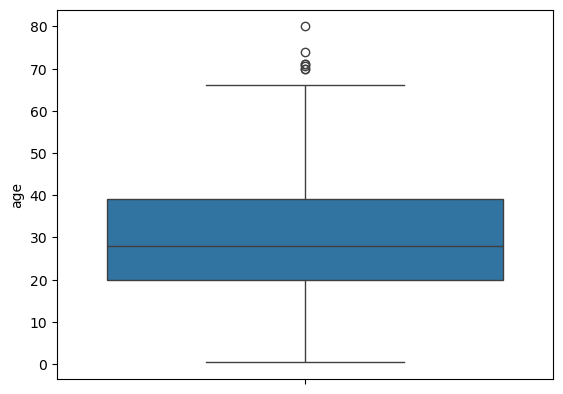

In [58]:
sns.boxplot(y='age',data=data)
plt.show()

In [60]:
data.age.describe()

count    676.000000
mean      29.812751
std       14.727098
min        0.420000
25%       20.000000
50%       28.000000
75%       39.000000
max       80.000000
Name: age, dtype: float64

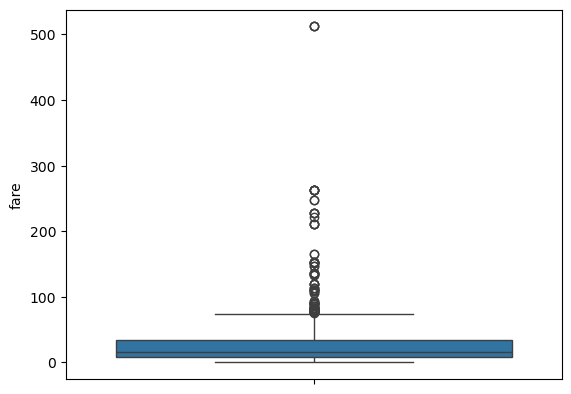

In [62]:
sns.boxplot(y='fare',data=data)
plt.show()

In [64]:
data.fare.describe()

count    780.000000
mean      34.829108
std       52.263440
min        0.000000
25%        8.050000
50%       15.950000
75%       34.375000
max      512.329200
Name: fare, dtype: float64

### Both the age and fare columns contain outliers.

## Removing outliers using IQR Method

In [68]:
# User Defined function to remove outliers
def outlier(dt):
    Q1=dt.quantile(0.25)
    Q3=dt.quantile(0.75)

    IQR = Q3-Q1
    Upper_Bound = Q3 + 1.5*IQR
    Lower_Bound = Q1 - 1.5*IQR
    
    return dt.clip(Upper_Bound,Lower_Bound)

In [70]:
data['Age']=outlier(data.age)

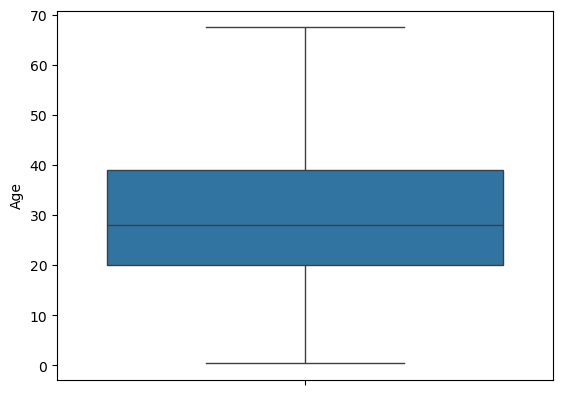

In [72]:
sns.boxplot(y='Age',data=data)
plt.show()

In [74]:
data['Fare']=outlier(data.fare)

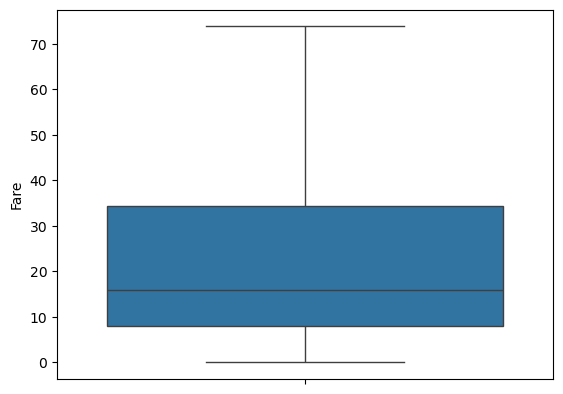

In [76]:
sns.boxplot(y='Fare',data=data)
plt.show()

In [78]:
data.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,Age,Fare
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,22.0,7.2500
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,38.0,71.2833
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,26.0,7.9250
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,35.0,53.1000
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,35.0,8.0500
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,Queenstown,no,True,NaN,8.4583
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,Southampton,no,True,54.0,51.8625
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,Southampton,no,False,2.0,21.0750
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,Southampton,yes,False,27.0,11.1333
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,Cherbourg,yes,False,14.0,30.0708


## Fill null values in age column with the median.

In [81]:
data['Age'] = data['Age'].fillna(data['age'].median())

In [83]:
data.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,Age,Fare
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,22.0,7.2500
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,38.0,71.2833
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,26.0,7.9250
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,35.0,53.1000
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,35.0,8.0500
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,Queenstown,no,True,28.0,8.4583
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,Southampton,no,True,54.0,51.8625
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,Southampton,no,False,2.0,21.0750
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,Southampton,yes,False,27.0,11.1333
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,Cherbourg,yes,False,14.0,30.0708


# Analysis

## Passenger Count by Survival Status and Passenger Type

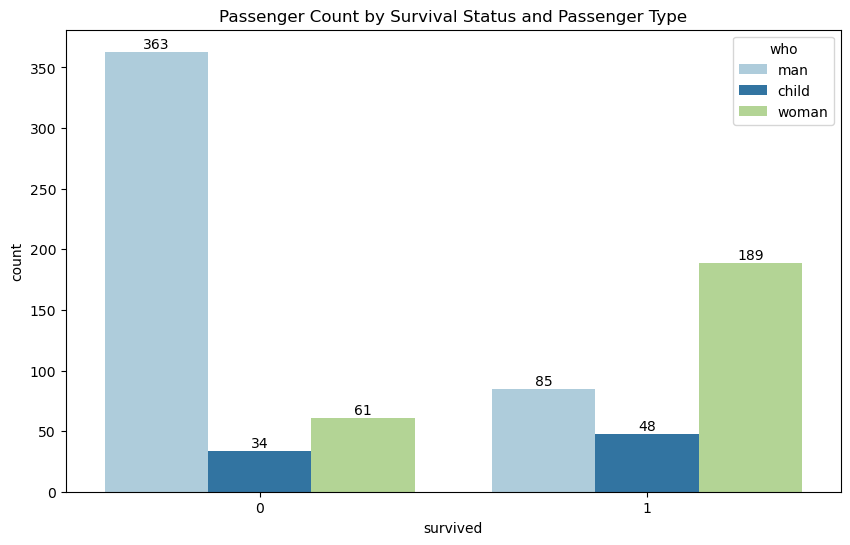

In [87]:
plt.figure(figsize=(10,6),dpi=100)
plot1 = sns.countplot(x='survived',data=data,hue='who',palette='Paired')
for i in plot1.containers:
    plot1.bar_label(i,fmt='%.f')
plt.title('Passenger Count by Survival Status and Passenger Type')
plt.show()

## Distribution of embark_town

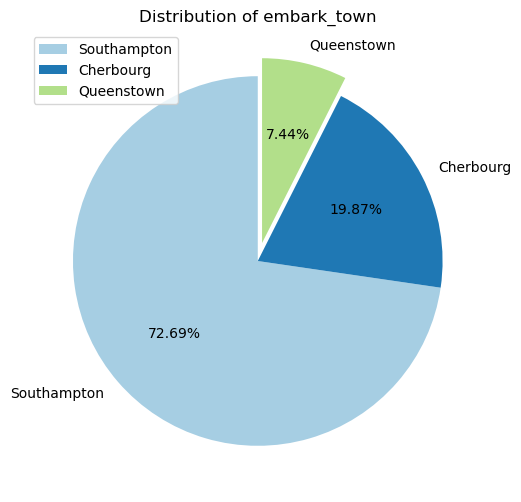

In [90]:
plt.figure(figsize=(10,6),dpi=100)
explode = [0, 0, 0.1]
colors = sns.color_palette("Paired")
plt.pie(data.embark_town.value_counts(),labels=data.embark_town.value_counts().index,autopct='%.2f%%',startangle=90, explode=explode, colors=colors)
plt.title('Distribution of embark_town')
plt.legend()
plt.show()

## Passenger Count by Class

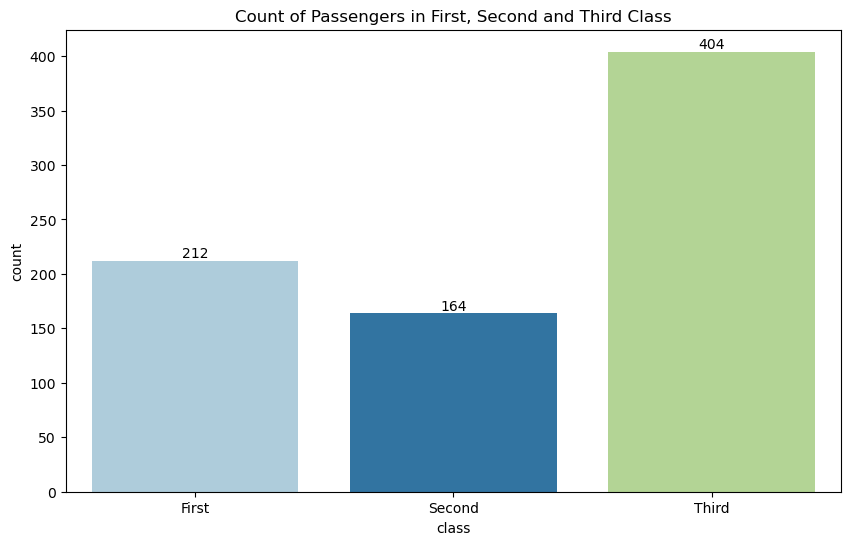

In [93]:
plt.figure(figsize=(10,6),dpi=100)
plot2 = sns.countplot(x='class',data=data,hue='class',palette='Paired')
for i in plot2.containers:
    plot2.bar_label(i,fmt='%.f')
plt.title('Count of Passengers in First, Second and Third Class')
plt.show()

## Distribution of Passenger Classes

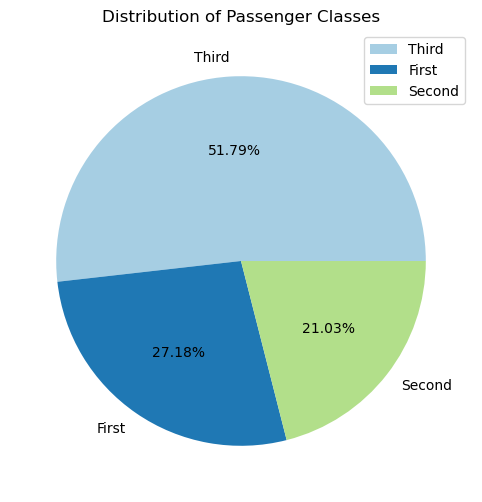

In [96]:
plt.figure(figsize=(10,6),dpi=100)
colors = sns.color_palette("Paired")
plt.pie(data['class'].value_counts(),labels=data['class'].value_counts().index,autopct='%.2f%%',colors=colors)
plt.title('Distribution of Passenger Classes')
plt.legend()
plt.show()

## Average age by Survival Status and Passenger gender

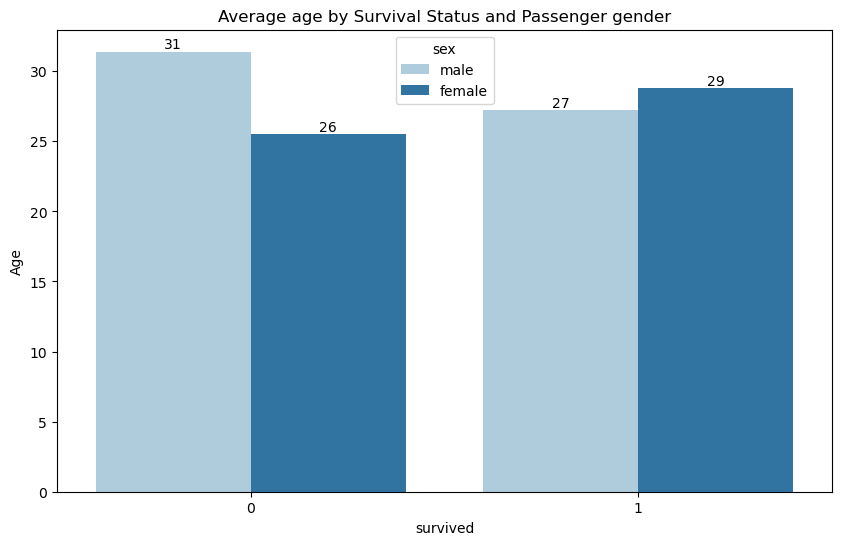

In [99]:
plt.figure(figsize = (10,6),dpi=100)
plot3 =sns.barplot(x='survived',y='Age',data=data,errorbar=('ci',False),hue='sex',palette='Paired')
for i in plot3.containers:
    plot3.bar_label(i,fmt='%.f')
plt.title('Average age by Survival Status and Passenger gender')
plt.show()

## Relationship between Age and Fare on the basis of Embark_town

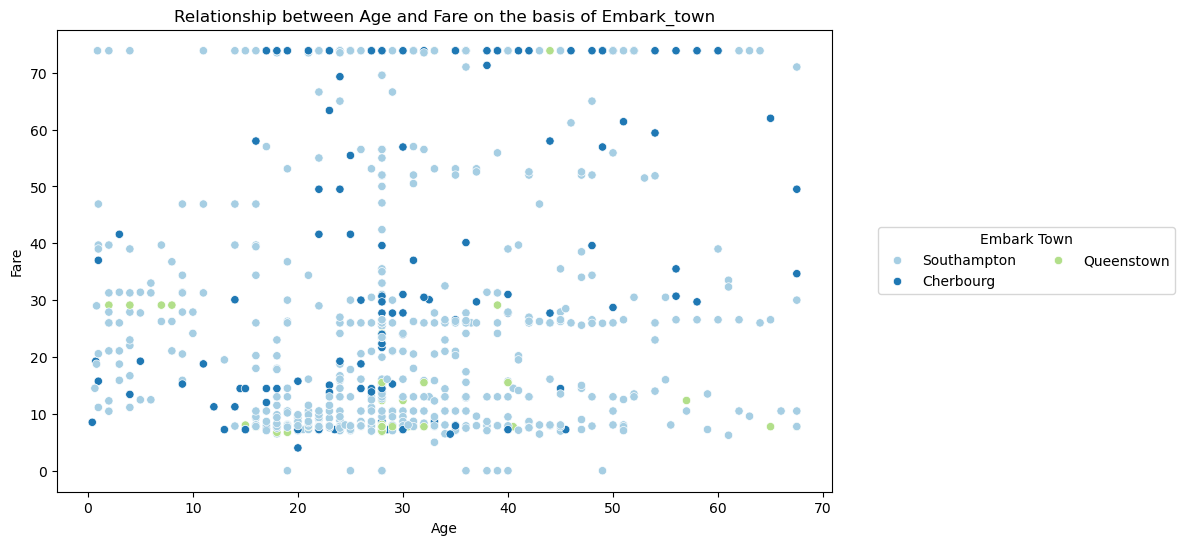

In [102]:
plt.figure(figsize=(10,6),dpi=100)
sns.scatterplot(x='Age',y='Fare',hue='embark_town',data=data,palette="Paired")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.legend(
    loc='center left',       
    bbox_to_anchor=(1.05, 0.5),
    ncol=2,                 
    title="Embark Town"
)
plt.title("Relationship between Age and Fare on the basis of Embark_town")
plt.show()

## Average Fare according to passenger class

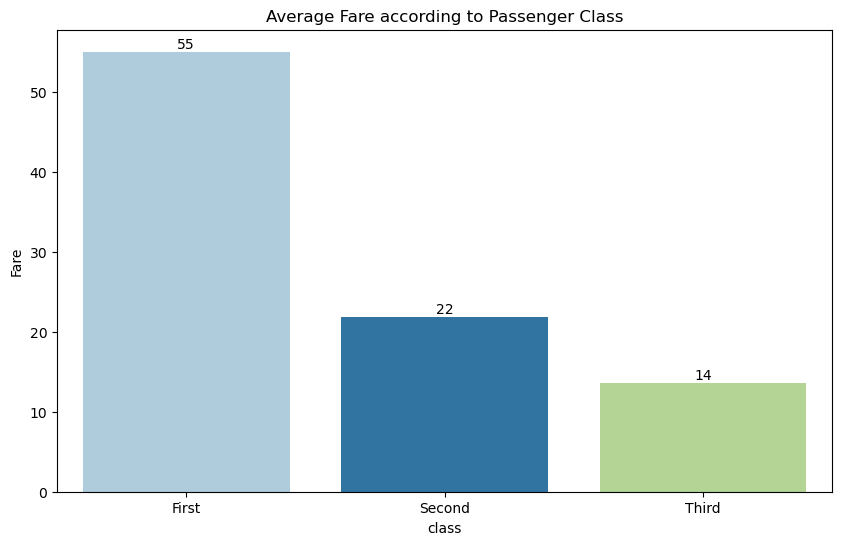

In [105]:
plt.figure(figsize = (10,6),dpi=100)
plot4 =sns.barplot(x='class',y='Fare',data=data,errorbar=('ci',False),hue='class',palette='Paired')
for i in plot4.containers:
    plot4.bar_label(i,fmt='%.f')
plt.title('Average Fare according to Passenger Class')
plt.show()

## Age Distribution by Passenger Class

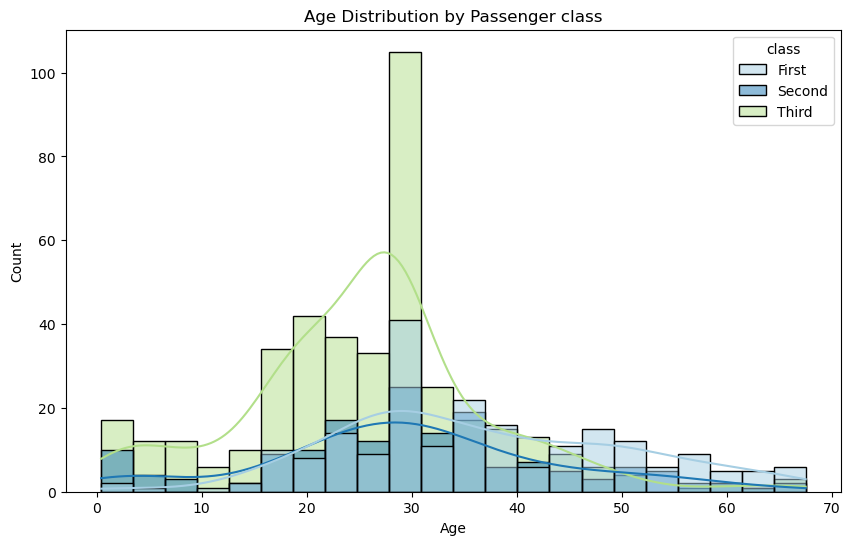

In [108]:
plt.figure(figsize=(10,6), dpi=100)
sns.histplot(data=data, x='Age', kde=True, hue='class', palette="Paired")
plt.title("Age Distribution by Passenger class")
plt.show()


## Average Fare by Embark town

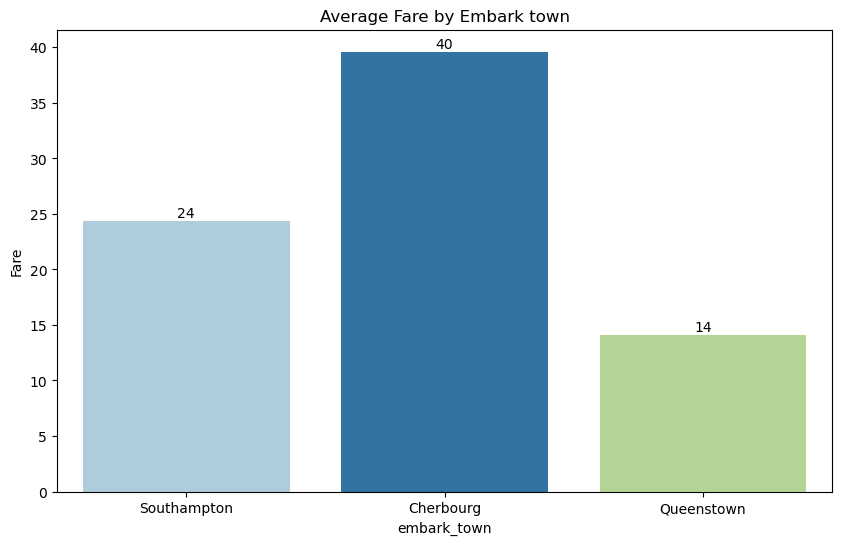

In [111]:
plt.figure(figsize = (10,6),dpi=100)
plot5 = sns.barplot(x='embark_town',y='Fare',data=data,errorbar=('ci',False),hue='embark_town',palette='Paired')
for i in plot5.containers:
    plot5.bar_label(i,fmt='%.f')
plt.title('Average Fare by Embark town')
plt.show()

## Age Distribution by Survival Status and Passenger Type

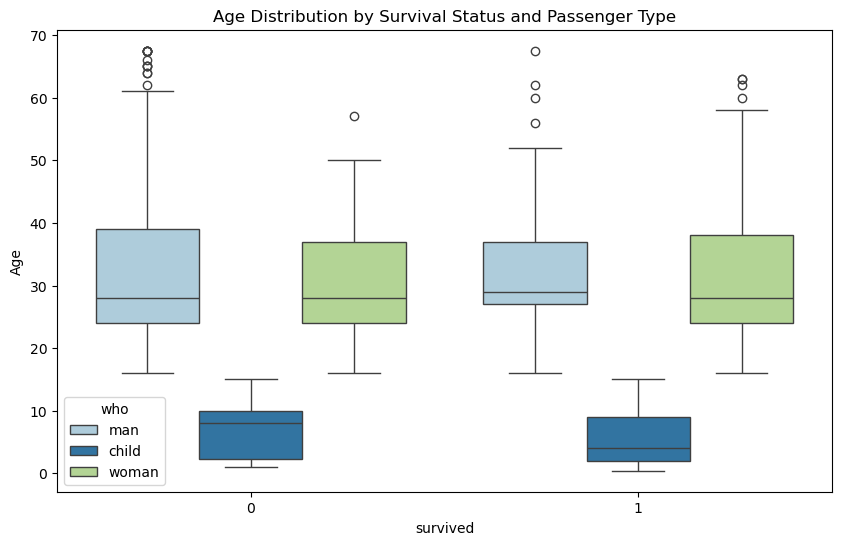

In [114]:
plt.figure(figsize=(10,6),dpi=100)
sns.boxplot(data=data, x='survived', y='Age', hue="who", palette="Paired")
plt.title("Age Distribution by Survival Status and Passenger Type")
plt.show()

## Correlation

In [117]:
selected_columns = ['survived','pclass','Age','sibsp','parch','Fare',]
df = data[selected_columns]

In [119]:
df.corr()

,survived,pclass,Age,sibsp,parch,Fare
survived,1.000000,-0.336244,-0.078309,-0.037597,0.069669,0.306086
pclass,-0.336244,1.000000,-0.342265,0.086788,0.038975,-0.737490
Age,-0.078309,-0.342265,1.000000,-0.279909,-0.182634,0.145921
sibsp,-0.037597,0.086788,-0.279909,1.000000,0.380596,0.261190
parch,0.069669,0.038975,-0.182634,0.380596,1.000000,0.237516
Fare,0.306086,-0.737490,0.145921,0.261190,0.237516,1.000000


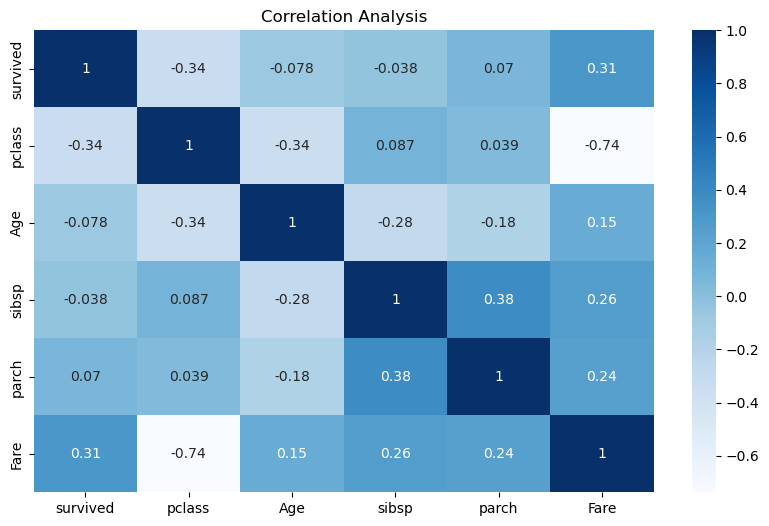

In [121]:
plt.figure(figsize=(10,6),dpi=100)
plt.title('Correlation Analysis')
sns.heatmap(df.corr(),annot=True,cmap="Blues")
plt.show()